In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

In [2]:
data = pd.read_csv("/Users/iraklisdimitriadis/Documents/Μαθήματα-Σημειώσεις Data Science/Dissertation/Processed Data/cleaned_data_csv.csv", index_col= "datetime", parse_dates= True)
data.head()

,Kwh,name,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon
datetime,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,0.0,"Kozani, Greece",6.0,4.4,2.0,75.51,0.0,0.0,0.0,19.8,7.6,240.0,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 01:00:00,0.0,"Kozani, Greece",6.0,5.0,2.0,75.51,0.0,0.0,0.0,19.8,5.4,298.1,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 02:00:00,0.0,"Kozani, Greece",4.9,3.2,2.0,81.61,0.0,NaN,0.0,20.5,7.6,301.0,1022.4,40.9,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 03:00:00,0.0,"Kozani, Greece",4.0,4.0,1.0,80.80,0.0,NaN,0.0,20.5,3.6,294.8,1022.0,38.0,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 04:00:00,0.0,"Kozani, Greece",3.0,1.6,2.0,93.14,0.0,NaN,0.0,19.8,5.4,292.3,1021.0,41.7,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night


In [3]:
df_13_00 = data[data.index.time == pd.Timestamp('13:00:00').time()]
mean_13_00 = data[data.index.time == pd.Timestamp('13:00:00').time()]['solarradiation'].mean()

df_13_00, mean_13_00

(                        Kwh            name  temp  feelslike   dew  humidity  \
 datetime                                                                       
 2022-01-01 13:00:00  0.4263  Kozani, Greece  14.0       14.0   3.0     47.46   
 2022-01-02 13:00:00  0.4391  Kozani, Greece  14.0       14.0   1.0     41.15   
 2022-01-03 13:00:00  0.4421  Kozani, Greece  13.0       13.0   3.0     50.65   
 2022-01-04 13:00:00  0.4611  Kozani, Greece  11.0       11.0   0.0     46.61   
 2022-01-05 13:00:00  0.4397  Kozani, Greece  14.0       14.0   2.0     44.20   
 ...                     ...             ...   ...        ...   ...       ...   
 2024-06-30 13:00:00  0.6883  Kozani, Greece  31.0       29.1   7.0     22.30   
 2024-07-01 13:00:00  0.6906  Kozani, Greece  33.9       32.2  10.6     24.14   
 2024-07-02 13:00:00  0.4582  Kozani, Greece  31.0       29.5  10.0     27.32   
 2024-07-03 13:00:00  0.7472  Kozani, Greece  25.0       25.0   9.0     36.24   
 2024-07-04 13:00:00  0.6692

In [4]:
data['solarradiation'].fillna(mean_13_00, inplace=True)

# ARIMA Models

In [ ]:
arima_models = auto_arima(data["Kwh"], trace= True, suppress_warnings= True)

# Split Data

In [6]:
x_train = data["Kwh"][: -168]
x_test = data["Kwh"][-168: ]
x_train.shape, x_test.shape

((21815,), (168,))

In [7]:
model = ARIMA(x_test, order = (2, 1, 2))
model_fit = model.fit()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [8]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                    Kwh   No. Observations:                  168
Model:                 ARIMA(2, 1, 2)   Log Likelihood                 203.353
Date:                Sun, 08 Dec 2024   AIC                           -396.707
Time:                        15:21:51   BIC                           -381.117
Sample:                    06-28-2024   HQIC                          -390.379
                         - 07-04-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.8888      0.020     92.460      0.000       1.849       1.929
ar.L2         -0.9600      0.020    -48.398      0.000      -0.999      -0.921
ma.L1         -1.9213      0.046    -41.546      0.000      -2.012      -1.831
ma.L2          0.9221      0.044     21.029      0.000       0.836       1.008
sigma2         0.0049      0.000     13.438      0.000       0.004       0.006
===================================================================================
Ljung-Box (L1) (Q):                   1.20   Jarque-Bera (JB):               185.63
Prob(Q):                              0.27   Prob(JB):                         0.00
Heteroskedasticity (H):               1.47   Skew:                            -1.01
Prob(H) (two-sided):                  0.15   Kurtosis:                         7.75
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [9]:
start_0 = len(x_train)
end_0 = start_0 + len(x_test) - 1
predictions_0 = model_fit.predict(start= start_0, end= end_0, typ='levels')

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


In [10]:
predictions_0.index = x_test.index

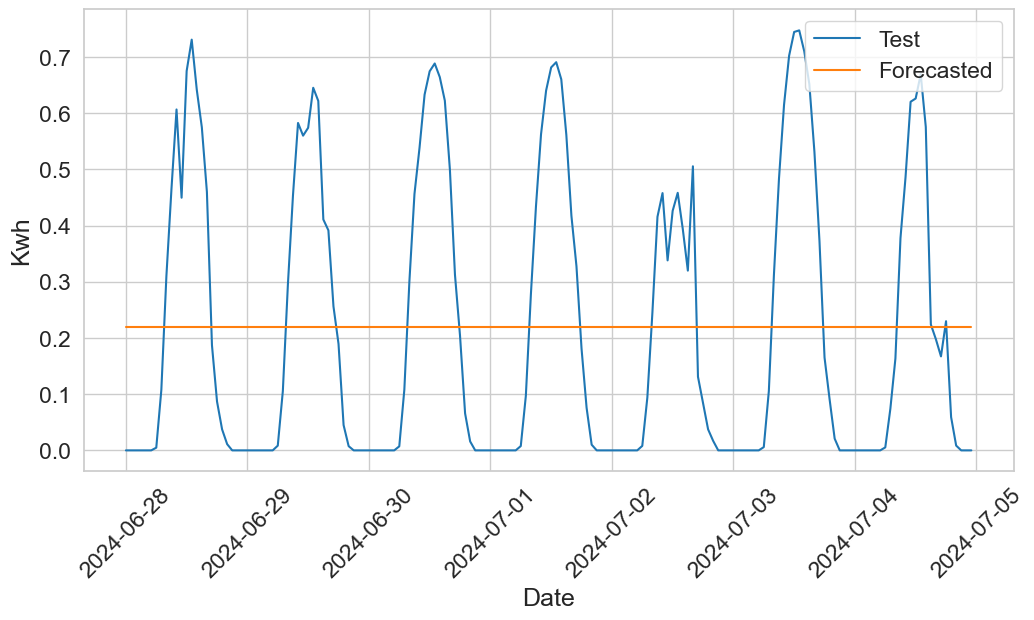

In [11]:
plt.figure(figsize=(12, 6))
#plt.plot(x_train, label='Train')
sns.set_context("notebook", font_scale=1.5)
sns.set_style("whitegrid")
plt.plot(x_test, label='Test')
plt.plot(predictions_0, label='Forecasted')
#plt.title('Actual vs Forecasted Kwh')
plt.xlabel('Date')
plt.ylabel('Kwh')
plt.xticks(rotation = 45)

plt.legend(loc = "upper right")
plt.show()

### Really bad predictions. But we can see that the Arima model calculated the mean value of the forecasted values very accurately!!

# SARIMA Model

In [12]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(x_train)
print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -7.99957422528152
p-value: 2.3536989455651775e-12


In [13]:
model_sarima = SARIMAX(x_train, order=(2, 1, 2), seasonal_order=(1, 1, 1, 24))
model_sarima_fit = model_sarima.fit()
print(model_sarima_fit.summary())

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


RUNNING THE L-BFGS-B CODE

           * * *



 This problem is unconstrained.


Machine precision = 2.220D-16
 N =            7     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f= -1.33664D+00    |proj g|=  5.08879D+00

At iterate    5    f= -1.39000D+00    |proj g|=  1.04484D-01

At iterate   10    f= -1.39558D+00    |proj g|=  1.71978D+00

At iterate   15    f= -1.41091D+00    |proj g|=  1.08262D+00

At iterate   20    f= -1.43563D+00    |proj g|=  9.47608D-01

At iterate   25    f= -1.43794D+00    |proj g|=  5.76196D-01

At iterate   30    f= -1.44889D+00    |proj g|=  1.24722D-01

At iterate   35    f= -1.45229D+00    |proj g|=  8.87066D-02

At iterate   40    f= -1.45268D+00    |proj g|=  4.18027D-02

At iterate   45    f= -1.45377D+00    |proj g|=  1.99931D-01


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



At iterate   50    f= -1.45581D+00    |proj g|=  5.67731D-02

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    7     50     62      1     0     0   5.677D-02  -1.456D+00
  F =  -1.4558067741967529     

STOP: TOTAL NO. of ITERATIONS REACHED LIMIT                 
                                      SARIMAX Results                                       
Dep. Variable:                                  Kwh   No. Observations:                21815
Model:             SARIMAX(2, 1, 2)x(1, 1, [1], 24)   Log Likelihood               31758.425
Date:                              Sun, 08 Dec 2024   AIC                         

### seasonal_order(1, 1, 1, 24) $\rightarrow$ 66.27%
### seasonal_order(1, 1, 2, 24) $\rightarrow$ 62.36%
### seasonal_order(2, 1, 2, 24) $\rightarrow$ 62.51%


In [14]:
x_train.index = pd.to_datetime(x_train.index)
x_test.index = pd.to_datetime(x_test.index)

In [15]:
start = pd.Timestamp('2024-06-28 00:00:00')
end = pd.Timestamp('2024-07-04 23:00:00')

forecast = model_sarima_fit.get_forecast(steps=len(x_test))
predictions = forecast.predicted_mean
predictions.index = x_test.index

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [16]:
result = pd.DataFrame({
    "predicted_mean": predictions,
    "Real": x_test
}, index=x_test.index)

In [17]:
result["predicted_mean"] = result["predicted_mean"].apply(lambda x: max(0, x))


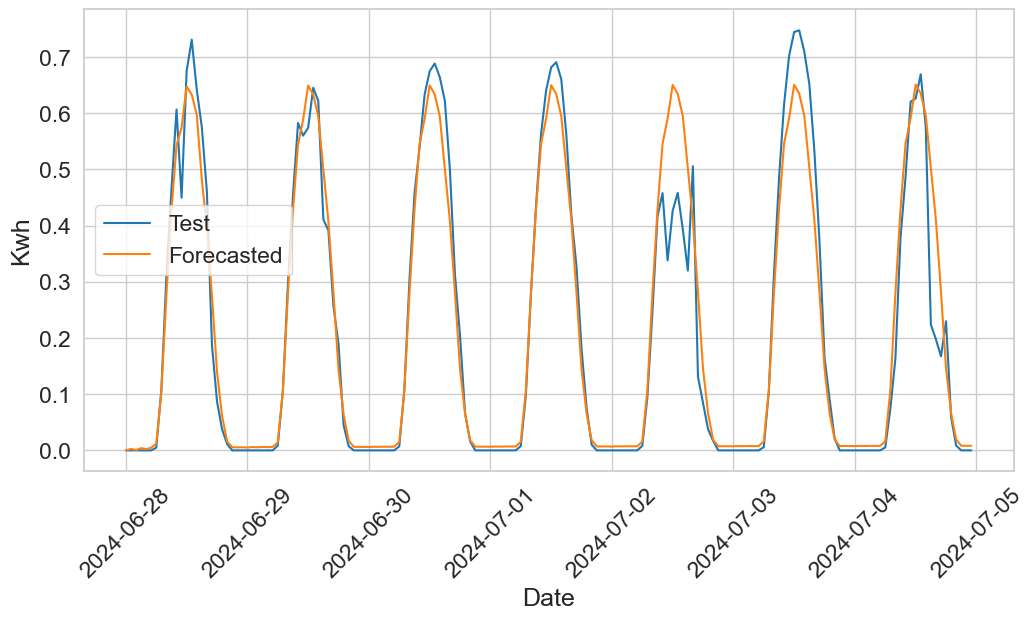

In [18]:
plt.figure(figsize=(12, 6))
#plt.plot(x_train, label='Train')
sns.set_context("notebook", font_scale=1.5)
sns.set_style("whitegrid")
plt.plot(result['Real'], label='Test')
plt.plot(result['predicted_mean'], label='Forecasted')
#plt.title('Actual vs Forecasted Kwh')
plt.xlabel('Date')
plt.ylabel('Kwh')
plt.xticks(rotation = 45)
plt.legend(loc = "upper right")
plt.legend()
plt.show()

In [19]:
mse = mean_squared_error(result['Real'], result['predicted_mean'])
print(f" Mean Squared Error = {round(mse, 5)} \n Root Mean Squared Error = {round(np.sqrt(mse), 5)}")
ss_total = np.sum((result['Real'] - result['Real'].mean()) ** 2)
residual = np.sum((result['Real'] - result['predicted_mean']) ** 2)
r_squared = 1 - (residual / ss_total)

r_squared

 Mean Squared Error = 0.00401 
 Root Mean Squared Error = 0.06334


0.9383888237751904

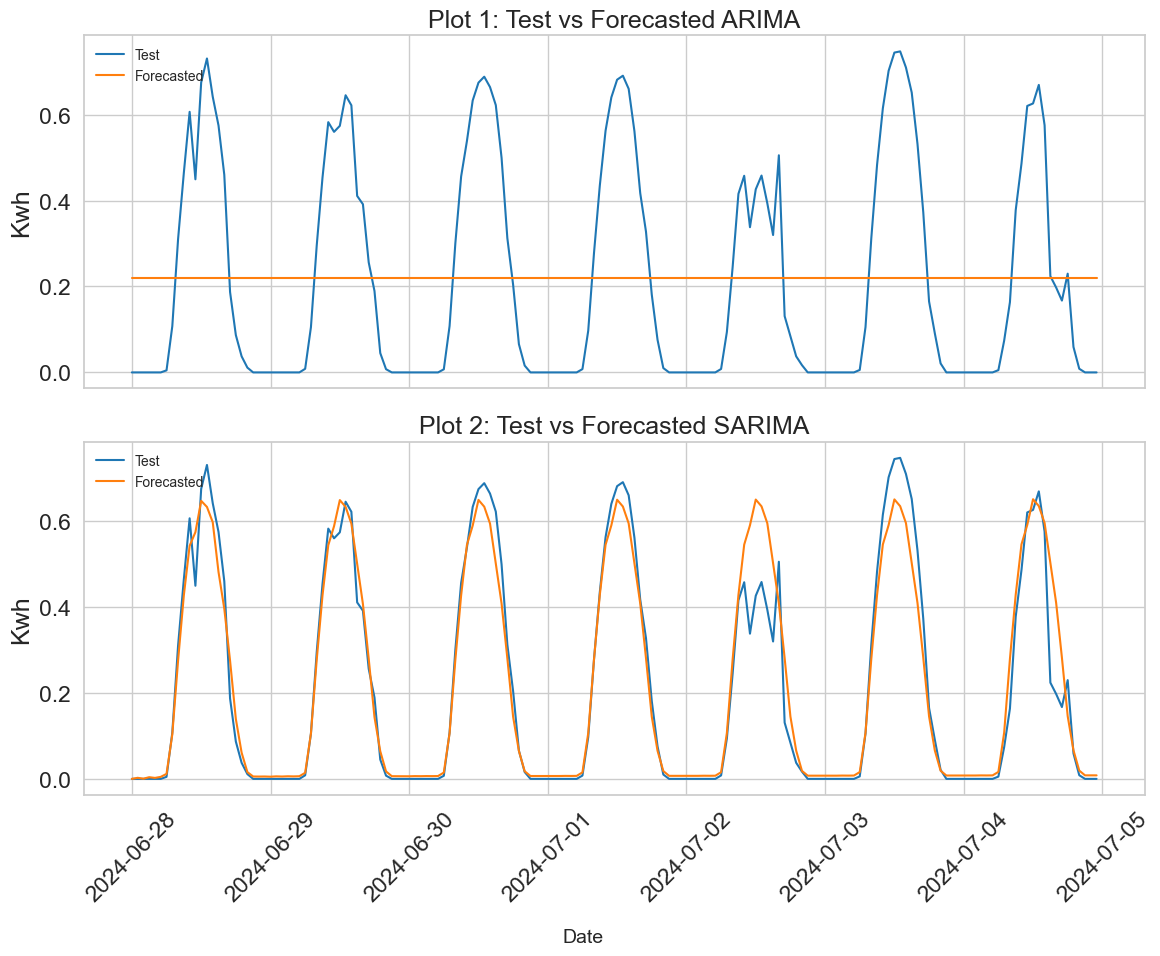

In [23]:
sns.set_context("notebook", font_scale=1.5)
sns.set_style("whitegrid")

fig, axs = plt.subplots(2, 1, figsize=(12, 10), sharex=True)  

axs[0].plot(x_test, label='Test')
axs[0].plot(predictions_0, label='Forecasted')
axs[0].set_ylabel('Kwh')
axs[0].set_title("Plot 1: Test vs Forecasted ARIMA")
axs[0].legend(loc='upper left', fontsize=10, frameon=False)

axs[1].plot(result['Real'], label='Test')
axs[1].plot(result['predicted_mean'], label='Forecasted')
axs[1].set_ylabel('Kwh')
axs[1].set_title("Plot 2: Test vs Forecasted SARIMA")
axs[1].legend(loc='upper left', fontsize=10, frameon=False)

fig.text(0.5, 0.04, "Date", ha='center', fontsize=14)

plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0.05, 1, 1])  

plt.show()
